# Tiny VCM — training from scratch and measured INT8 deployment
**Crizepvill F. Dumalaog · 202521406 · AI 231 ME2**

This is the current reproducible notebook. The older notebook is retained as historical work.
**Provisional dataset:** existing Windows SAPI synthetic speech is not recordings of three people.
No pretrained recognition weights or ASR are used. A fresh DS-CNN is initialized below.
Human recognition and Raspberry Pi performance are unverified until those experiments run.

Run **Run → Run All Cells**. Epoch output appears during training. Switch `DATA_MODE` to `human`
after completing `record_dataset.py` with three real speakers, every class and multiple conditions.
The last speaker ID is test-only; the penultimate is validation-only. Four or more people are preferable.


In [1]:
from pathlib import Path
import sys, json
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "tinyvcm").is_dir())
sys.path.insert(0, str(ROOT))
from tinyvcm.training import prepare, train, export_and_evaluate
DATA_MODE = "synthetic_baseline"  # change to "human" only after recording
EPOCHS = 100
ctx = prepare(DATA_MODE, seed=231)

{
  "mode": "synthetic_baseline",
  "human_dataset_requirement_met": false,
  "voices_or_speakers": [
    "David",
    "Hazel",
    "Zira"
  ],
  "test_speaker": "Zira",
  "counts": {
    "train": 1688,
    "val": 826,
    "test": 1221
  },
  "classes": 26,
  "source_groups_disjoint": true,
  "sha256_split_overlap": false,
  "warning": "Synthetic voices are not people; results do not establish human recognition."
}
train: 1688 examples, features (1688, 1, 40, 151)
val: 826 examples, features (826, 1, 40, 151)
test: 1221 examples, features (1221, 1, 40, 151)
Random-start TinyDSCNN-48: 14,282 parameters on cuda. Run: 20260926-111536


## Dataset and evaluation boundary
The synthetic baseline holds out one complete TTS voice. The remaining voices' +2 speech-rate
groups are validation only. Base utterances and their pitch/time variants stay together.
SHA-256 checks reject identical WAV files across splits. Synthetic noise is labeled as such.
Existing legacy audio is only 1.5 seconds and may already contain truncated phrases; this run cannot
repair missing speech. New human collection rejects clipped/overlong recordings.

There are 23 fixed intents spanning the earlier project's ten categories, one wake class and two
background classes. A collected human dataset adds unrelated speech (`_unknown_`). This recognizes
a limited vocabulary, not free-form conversation or arbitrary timer values.


Labels: 26
play_music             Play music
media_pause            Pause music
media_resume           Resume music
media_next             Next song
volume_up              Volume up
volume_down            Volume down
question_weather       What is the weather
question_time          What time is it
lights_on              Turn on the lights
lights_off             Turn off the lights
dim_lights_25          Dim lights to twenty five percent
dim_lights_50          Dim lights to fifty percent
dim_lights_75          Dim lights to seventy five percent
dim_lights_100         Lights to maximum
timer_1min             Timer for one minute
timer_5min             Timer for five minutes
timer_10min            Timer for ten minutes
alarm_set              Set alarm for seven AM
temp_cooler            Make it cooler
temp_warmer            Make it warmer
temp_set_72            Set temperature to seventy two degrees
reminders_check        Check my reminders
call_mom               Call mom
wake_word       

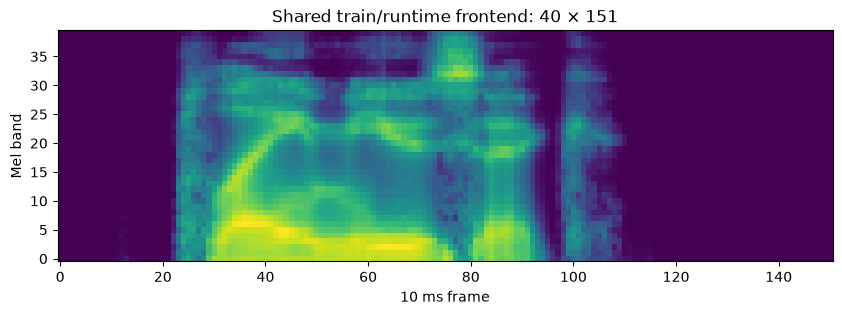

In [2]:
import matplotlib.pyplot as plt
from tinyvcm.config import PHRASES
print("Labels:", len(ctx["labels"]))
for name in ctx["labels"]:
    print(f"{name:22} {PHRASES[name]}")
plt.figure(figsize=(10,3))
plt.imshow(ctx["splits"]["train"][0][0,0], origin="lower", aspect="auto")
plt.xlabel("10 ms frame"); plt.ylabel("Mel band"); plt.title("Shared train/runtime frontend: 40 × 151")
plt.show()

## Acoustic frontend and network
At 16 kHz, a periodic 400-sample Hann window covers 25 ms, with a 160-sample (10 ms) hop
and a 512-point FFT. Reflect-centered framing gives 151 frames for 1.5 seconds.
Forty Slaney mel filters summarize squared FFT magnitude, followed by `log(power + 1e-6)`
and per-window standardization. Exactly the same NumPy implementation runs on Windows and Pi.

The DS-CNN uses a 48-channel stem, four depthwise/pointwise blocks, global average pooling and
a classifier. A depthwise 3×3 and pointwise 1×1 pair costs `9C + C²` weights instead of `9C²`.
This is a DS-CNN, not the published BC-ResNet-1; the old custom attention network remains in `src/`.
AdamW, train-only noise mixing and masking, and a cosine learning-rate schedule are used.
Validation selects the checkpoint. Test data is never used by the optimizer or INT8 calibration.


In [3]:
history = train(ctx, epochs=EPOCHS, batch_size=64)

Epoch 01/100 | loss 3.0491 | train 12.2% | val 13.7% | 1.4s
Epoch 02/100 | loss 2.7250 | train 18.1% | val 12.6% | 1.0s
Epoch 03/100 | loss 2.5395 | train 22.2% | val 21.5% | 1.0s
Epoch 04/100 | loss 2.3668 | train 28.7% | val 30.4% | 1.0s
Epoch 05/100 | loss 2.1837 | train 33.9% | val 36.8% | 1.0s
Epoch 06/100 | loss 2.0158 | train 40.1% | val 30.0% | 1.0s
Epoch 07/100 | loss 1.8273 | train 47.5% | val 39.0% | 1.0s
Epoch 08/100 | loss 1.6712 | train 52.9% | val 45.9% | 1.0s
Epoch 09/100 | loss 1.5353 | train 56.9% | val 55.6% | 1.0s
Epoch 10/100 | loss 1.4530 | train 58.9% | val 44.2% | 1.0s
Epoch 11/100 | loss 1.3400 | train 63.5% | val 58.5% | 1.0s
Epoch 12/100 | loss 1.2813 | train 65.8% | val 49.3% | 1.0s
Epoch 13/100 | loss 1.2212 | train 67.1% | val 59.0% | 1.0s
Epoch 14/100 | loss 1.1674 | train 70.2% | val 54.6% | 1.0s
Epoch 15/100 | loss 1.0996 | train 72.5% | val 67.3% | 1.0s
Epoch 16/100 | loss 1.0739 | train 73.6% | val 58.7% | 1.0s
Epoch 17/100 | loss 1.0250 | train 75.2%

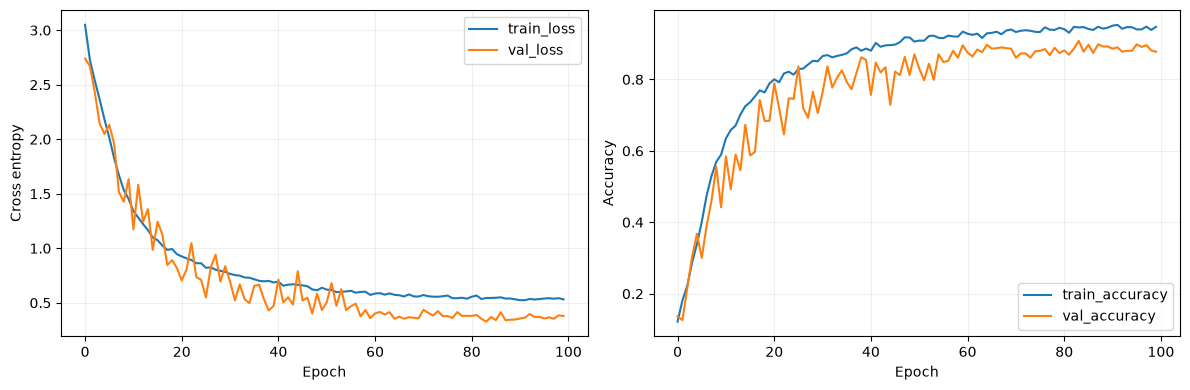

In [4]:
fig, ax = plt.subplots(1,2,figsize=(12,4))
for key in ["train_loss", "val_loss"]:
    ax[0].plot([r[key] for r in history], label=key)
for key in ["train_accuracy", "val_accuracy"]:
    ax[1].plot([r[key] for r in history], label=key)
for a in ax: a.legend(); a.set_xlabel("Epoch"); a.grid(alpha=.2)
ax[0].set_ylabel("Cross entropy"); ax[1].set_ylabel("Accuracy")
fig.tight_layout(); fig.savefig(ctx["run"] / "training_curves.png", dpi=140)
plt.show()

## Static INT8 export and held-out testing
ONNX Runtime calibrates activations using training examples only. Every convolution and dense
weight tensor is checked for INT8 storage. This differs from dynamic quantization, which did not
quantize the earlier convolution layers. Frontend and output probabilities remain floating point.
The actual serialized ONNX must be less than **500,000 bytes**.

Metrics below are measured on this Windows PC, not on a Raspberry Pi. Noise curves use held-out
synthetic noise. The runtime's 1.5-second audio context and two-window confirmation add response
time beyond the neural inference measurement. No human false-alarm/hour claim is made.


In [5]:
metrics = export_and_evaluate(ctx)

{
  "fp32_test_accuracy": 0.8108108108108109,
  "int8_test_accuracy": 0.7927927927927928,
  "test_count": 1221,
  "best_epoch": 84,
  "int8_bytes": 44640,
  "all_conv_and_dense_weights_int8": true,
  "quantized_learned_layers": 10,
  "prediction_agreement": 0.9279279279279279,
  "raspberry_pi_measured": false,
  "human_speech_measured": false,
  "synthetic_noise_snr_accuracy": {
    "20": 0.7375527426160338,
    "10": 0.5949367088607594,
    "0": 0.1839662447257384
  },
  "pc_benchmark": {
    "platform": "Windows-11-10.0.26200-SP0",
    "machine": "AMD64",
    "board": null,
    "is_raspberry_pi": false,
    "iterations": 200,
    "threads": 1,
    "model": {
      "p50_ms": 0.5498499958775938,
      "p95_ms": 0.6135749987151938,
      "p99_ms": 0.7571329994243565
    },
    "frontend_and_model": {
      "p50_ms": 1.239299999724608,
      "p95_ms": 1.7027549984049977,
      "p99_ms": 2.07967799346079
    },
    "process_rss_mb": 2243.6015625,
    "note": "Process RSS includes currentl

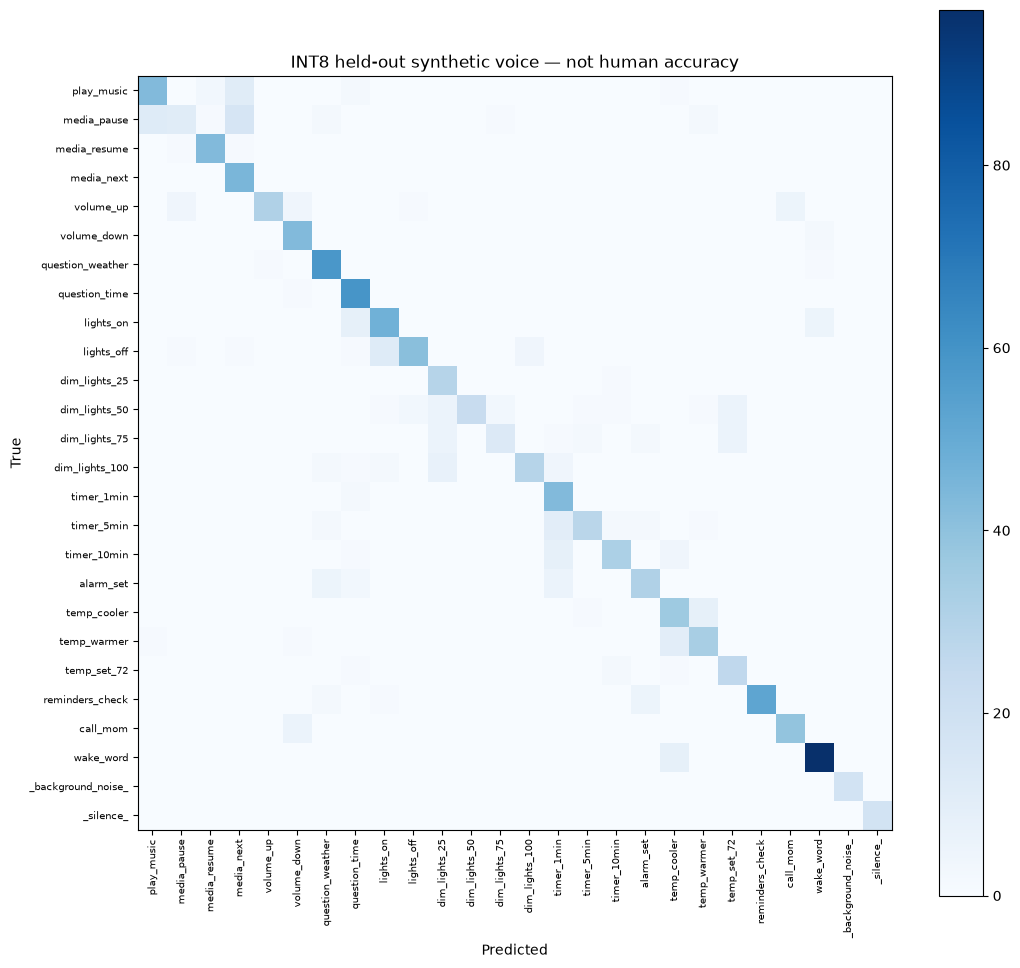

Run artifacts: C:\Users\danda\Desktop\MEng AI Notebooks\AI 222 231\AI 231\Dumalaog_ME2 - Tiny Voice Command Model\runs\20260926-111536
PC: Start-PC-Demo.ps1 at workspace root. Say Hi Dandan, pause for LISTENING, then a short command.


In [6]:
import numpy as np
fig, ax = plt.subplots(figsize=(11,10))
im=ax.imshow(metrics["confusion_matrix"],cmap="Blues")
ax.set_xticks(range(len(ctx["labels"])),ctx["labels"],rotation=90,fontsize=7)
ax.set_yticks(range(len(ctx["labels"])),ctx["labels"],fontsize=7)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("INT8 held-out synthetic voice — not human accuracy" if DATA_MODE != "human" else "INT8 held-out human speaker")
fig.colorbar(im,ax=ax); fig.tight_layout()
fig.savefig(ctx["run"] / "confusion_matrix.png",dpi=140); plt.show()
print("Run artifacts:",ctx["run"])
print("PC: Start-PC-Demo.ps1 at workspace root. Say Hi Dandan, pause for LISTENING, then a short command.")

## What remains for assignment completion
1. Record consenting humans (at least three), unrelated speech and real room noise under multiple
conditions. Retrain with `DATA_MODE="human"`. Synthetic voices do not meet this requirement.
2. Validate wake false rejects and false alarms over timed real continuous audio. Tune thresholds
using validation speakers only; report held-out results once.
3. Flash **Raspberry Pi OS 64-bit**, transfer the generated `release/` folder and run `setup_rpi.sh`.
The installer downloads dependencies once; runtime then works offline. A folder of Python files
is not a bootable SD image. Use USB or HDMI audio on Pi 5 (no built-in 3.5 mm audio jack).
4. Run `python -m tinyvcm.runtime --output pi_benchmark.json` on the actual Pi. Verify p95 inference,
resident memory, microphone capture, and wired LED/buzzer before declaring deployment complete.

References: [class lessons](https://github.com/roatienza/Deep-Learning-Experiments),
[PyTorch quantization](https://docs.pytorch.org/tutorials/recipes/quantization.html),
[Pi OS setup](https://www.raspberrypi.com/documentation/computers/getting-started.html).
Agent contribution: Codex audited earlier claims and generated this pipeline. Student review is still required.
